#### Import python files from another directory
In order to reuse code written in .py files you need to import them.
If they are from a distant folder, rather than copy-paste it into the current folder, you can write:

In [1]:
import sys

sys.path.append(
    "../../ex02/template"
)  # This goes up twice in the directories tree (hence in labs)
# then goes down to ex02/template where your files from lab 2 are.

you can now import your desired files, for example, we can import grid_search.py with:

In [2]:
import grid_search  # You then need to call your functions using grid_search.function_name()
import grid_search as gs  # You then need to call your functions using gs.function_name()
from grid_search import *  # You can call any functions of the file with function_name()

# Let's try to call generate_w from grid_search.py:
w0, w1 = generate_w(5)
print(w0, w1)

[-100.  -25.   50.  125.  200.] [-150.  -75.    0.   75.  150.]


As you can see we are now able to call functions from the grid_search.py file.

In [3]:
# Useful starting lines
%matplotlib inline
import numpy as np
import matplotlib.pyplot as plt
from helpers import *

from test_utils import test

%load_ext autoreload
%autoreload 2

# 1 Least squares and linear basis functions models
## 1.1 Least squares

In [4]:
def least_squares(y, tx):
    """Calculate the least squares solution.
       returns mse, and optimal weights.

    Args:
        y: numpy array of shape (N,), N is the number of samples.
        tx: numpy array of shape (N,D), D is the number of features.

    Returns:
        w: optimal weights, numpy array of shape(D,), D is the number of features.
        mse: scalar.

    >>> least_squares(np.array([0.1,0.2]), np.array([[2.3, 3.2], [1., 0.1]]))
    (array([ 0.21212121, -0.12121212]), 8.666684749742561e-33)
    """
    A = tx.T.dot(tx)
    b = tx.T.dot(y)
    w = np.linalg.solve(A, b)
    pred = tx.dot(w)
    err = y - pred
    mse = err.dot(err) / (2*len(err))
    return (w, mse)

### You can test your implementation here

In [5]:
test(least_squares)
# NB:
#
# Due to precision issues,
# the output might not be exactly the same
# even if you have implemented the right code.
#
# For example, the mse output expected to be
# 8.666684749742561e-33,
# but you might get some other small number
# close to zero.
#
# In this case,
# Failing the test doesn't necessarily mean
# your implementation is wrong.:)

❌ The are some issues with your implementation of `least_squares`:
**********************************************************************
File "__main__", line 13, in least_squares
Failed example:
    least_squares(np.array([0.1,0.2]), np.array([[2.3, 3.2], [1., 0.1]]))
Expected:
    (array([ 0.21212121, -0.12121212]), 8.666684749742561e-33)
Got:
    (array([ 0.21212121, -0.12121212]), np.float64(9.629649721936179e-33))
**********************************************************************


### Load the data
Here we will reuse the dataset `height_weight_genders.csv` from previous exercise section to check the correctness of your implementation. Please compare it with your previous result.

In [6]:
def test_your_least_squares(resolutions=(10, 25, 50, 100, 200)):
    """Compare the optimal weights obtained by least squares vs. grid search.

    Least squares solves the normal equations exactly, so it lower-bounds any
    grid search: the grid can only return a point it was told to try. Sweeping
    the resolution shows the gap shrinking as the cells get smaller, while
    always staying inside the half-cell bound.

    Args:
        resolutions: grid resolutions (num_intervals) to evaluate, coarse to fine.
    """
    height, weight, gender = load_data_from_ex02(sub_sample=False, add_outlier=False)
    x, mean_x, std_x = standardize(height)
    y, tx = build_model_data(x, weight)

    w_ls, mse_ls = least_squares(y, tx)
    print(f"least squares (exact):  w0={w_ls[0]:.6f}  w1={w_ls[1]:.6f}  mse={mse_ls:.6f}\n")
    header = f"{'n':>5}{'step':>9}{'w0':>11}{'w1':>11}{'mse':>11}{'||w-w*||':>11}{'mse-mse*':>11}"
    print(header + "\n" + "-" * len(header))

    errors, bounds = [], []
    for n in resolutions:
        grid_w0, grid_w1 = generate_w(n)
        losses = grid_search(y, tx, grid_w0, grid_w1)
        mse_gs, w0_gs, w1_gs = get_best_parameters(grid_w0, grid_w1, losses)
        step = grid_w0[1] - grid_w0[0]
        errors.append(np.linalg.norm(np.array([w0_gs, w1_gs]) - w_ls))
        bounds.append(0.5 * np.hypot(step, grid_w1[1] - grid_w1[0]))
        print(
            f"{n:5d}{step:9.3f}{w0_gs:11.4f}{w1_gs:11.4f}{mse_gs:11.4f}"
            f"{errors[-1]:11.4f}{mse_gs - mse_ls:11.4f}"
        )

    fig, (ax1, ax2, ax3) = plt.subplots(1, 3, figsize=(16, 4.5))

    # Left: the whole loss landscape, log-scaled or the bowl is invisible.
    mesh_w0, mesh_w1 = np.meshgrid(grid_w0, grid_w1)
    contour = ax1.contourf(mesh_w0, mesh_w1, np.log10(losses.T), levels=30, cmap="viridis")
    fig.colorbar(contour, ax=ax1, label=r"$\log_{10}$ MSE")
    ax1.plot(*w_ls, "w*", markersize=16, label="least squares")
    ax1.plot(w0_gs, w1_gs, "rx", markersize=10, mew=2, label=f"grid best (n={n})")
    ax1.set(xlabel=r"$w_0$", ylabel=r"$w_1$", title="loss landscape")
    ax1.legend(loc="upper right")

    # Middle: the candidates around the optimum, coloured by their loss.
    pad = 2.5 * step
    near_w0 = np.abs(grid_w0 - w_ls[0]) <= pad
    near_w1 = np.abs(grid_w1 - w_ls[1]) <= pad
    zoom_w0, zoom_w1 = np.meshgrid(grid_w0[near_w0], grid_w1[near_w1])
    ax2.scatter(
        zoom_w0,
        zoom_w1,
        c=np.log10(losses[np.ix_(near_w0, near_w1)].T),
        cmap="viridis",
        s=70,
    )
    ax2.plot([w_ls[0], w0_gs], [w_ls[1], w1_gs], "r--", lw=1)
    ax2.plot(*w_ls, "k*", markersize=16, label="least squares")
    ax2.plot(w0_gs, w1_gs, "rx", markersize=10, mew=2, label=f"grid best, off by {errors[-1]:.2f}")
    ax2.set(
        xlabel=r"$w_0$",
        ylabel=r"$w_1$",
        title=f"candidates near the optimum (step={step:.2f})",
    )
    ax2.legend(loc="upper right")

    # Right: how the gap closes as the grid is refined.
    ax3.loglog(resolutions, errors, "o-", label=r"$\|w_{gs}-w_{ls}\|$")
    ax3.loglog(resolutions, bounds, "k--", label="half-cell bound")
    ax3.set(xlabel="num_intervals", ylabel="distance to optimum", title="error vs. grid resolution")
    ax3.legend()
    ax3.grid(which="both", alpha=0.3)

    plt.tight_layout()
    plt.show()

Test it here

least squares (exact):  w0=73.293922  w1=13.479712  mse=15.385888

    n     step         w0         w1        mse   ||w-w*||   mse-mse*
---------------------------------------------------------------------
   10   33.333    66.6667    16.6667    42.4245     7.3537    27.0386
   25   12.500    75.0000    12.5000    17.3212     1.9674     1.9353
   50    6.122    71.4286    15.3061    18.7935     2.6106     3.4077


  100    3.030    72.7273    13.6364    15.5587     0.5879     0.1728


  200    1.508    73.3668    12.8141    15.6101     0.6696     0.2242


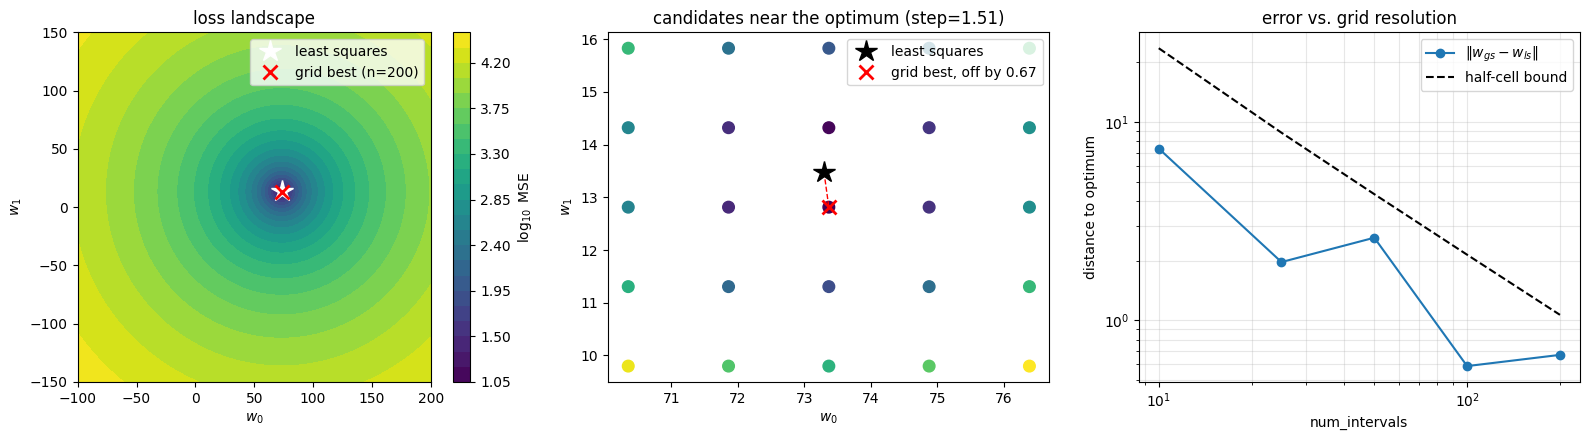

In [7]:
test_your_least_squares()

## 1.2 Least squares with a linear basis function model
Start from this section, we will use the dataset `dataEx3.csv`.

### Implement polynomial basis functions

In [8]:
# load dataset
x, y = load_data()
print("shape of x {}".format(x.shape))
print("shape of y {}".format(y.shape))

shape of x (50,)
shape of y (50,)


In [9]:
def build_poly(x, degree):
    """polynomial basis functions for input data x, for j=0 up to j=degree.

    Args:
        x: numpy array of shape (N,), N is the number of samples.
        degree: integer.

    Returns:
        poly: numpy array of shape (N,d+1)

    >>> build_poly(np.array([0.0, 1.5]), 2)
    array([[1.  , 0.  , 0.  ],
           [1.  , 1.5 , 2.25]])
    """
    # extended_x = np.zeros((x.shape[0], degree + 1))
    # for i, val in enumerate(x): 
    #     for j in range(degree + 1):
    #         extended_x[i, j] = val ** j
    # return extended_x

    return x.reshape(-1,1) ** np.arange(degree + 1)

In [10]:
test(build_poly)

✅ Your `build_poly` passed 1 tests.


Once your implementation of `build_poly` passes the test, copy it to `build_polynomial.py`
Let us play with polynomial regression. Note that we will use your implemented function `compute_mse`. Please copy and paste your implementation from exercise02.

In [11]:
from plots import *


def polynomial_regression():
    """Constructing the polynomial basis function expansion of the data,
    and then running least squares regression."""
    # define parameters
    degrees = [1, 3, 7, 12]

    # define the structure of the figure
    num_row = 2
    num_col = 2
    f, axs = plt.subplots(num_row, num_col)

    for ind, degree in enumerate(degrees):
        poly = build_poly(x, degree)
        ls_weights, mse = least_squares(y, poly)
        rmse = np.sqrt(2 * mse)

        print(
            "Processing {i}th experiment, degree={d}, rmse={loss}".format(
                i=ind + 1, d=degree, loss=rmse
            )
        )
        # plot fit
        plot_fitted_curve(y, x, ls_weights, degree, axs[ind // num_col][ind % num_col])
    plt.tight_layout()

    plt.show()

Run polynomial regression

Processing 1th experiment, degree=1, rmse=0.47187607963421874
Processing 2th experiment, degree=3, rmse=0.25858277667737467
Processing 3th experiment, degree=7, rmse=0.24965870360906878
Processing 4th experiment, degree=12, rmse=0.24413842781194978


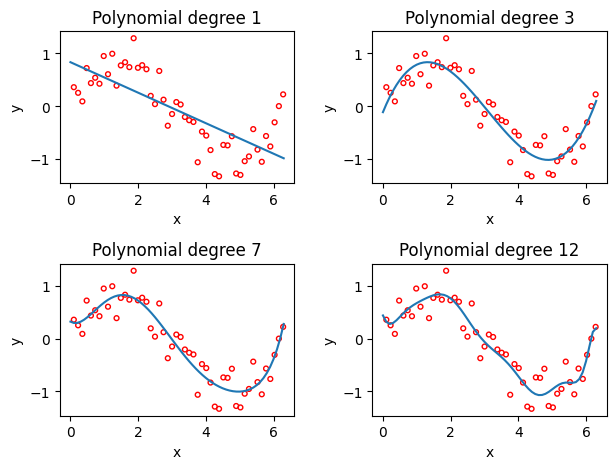

In [12]:
polynomial_regression()

Your results should look like this:

![alt text](visualize_polynomial_regression.png)

# 2 Evaluating model predication performance

Let us show the train and test splits for various polynomial degrees. First of all, please fill in the function `split_data()`

In [13]:
def split_data(x, y, ratio, seed=1):
    """
    split the dataset based on the split ratio. If ratio is 0.8
    you will have 80% of your data set dedicated to training
    and the rest dedicated to testing. If ratio times the number of samples is not round
    you can use np.floor. Also check the documentation for np.random.permutation,
    it could be useful.

    Args:
        x: numpy array of shape (N,), N is the number of samples.
        y: numpy array of shape (N,).
        ratio: scalar in [0,1]
        seed: integer.

    Returns:
        x_tr: numpy array containing the train data.
        x_te: numpy array containing the test data.
        y_tr: numpy array containing the train labels.
        y_te: numpy array containing the test labels.

    >>> split_data(np.arange(13), np.arange(13), 0.8, 1)
    (array([ 2,  3,  4, 10,  1,  6,  0,  7, 12,  9]), array([ 8, 11,  5]), array([ 2,  3,  4, 10,  1,  6,  0,  7, 12,  9]), array([ 8, 11,  5]))
    """
    # shuffle x and y with the same permutation (same seed)
    x = np.random.RandomState(seed).permutation(x)
    y = np.random.RandomState(seed).permutation(y)
    x_tr, x_te = np.split(x, [int(np.floor(len(x) * ratio))])
    y_tr, y_te = np.split(y, [int(np.floor(len(y) * ratio))])
    return x_tr, x_te, y_tr, y_te

In [14]:
test(split_data)

✅ Your `split_data` passed 1 tests.


Then, test your `split_data` function below.

In [15]:
def train_test_split_demo(x, y, degree, ratio, seed):
    """polynomial regression with different split ratios and different degrees.

    Returns:
      x_tr: numpy array
      x_te: numpy array
      y_tr: numpy array
      y_te: numpy array
      weights: weights from the least squares optimization"""
    
    # Split data into train and test sets
    x_tr, x_te, y_tr, y_te = split_data(x, y, ratio, seed)

    # Form train and test data with polynomial basis function
    x_tr_poly = build_poly(x_tr, degree)
    x_te_poly = build_poly(x_te, degree)

    # Calculate weight through least square
    w, mse = least_squares(y_tr, x_tr_poly)

    # Calculate RMSE for train and test data,
    rmse_tr = np.sqrt(2 * mse)
    rmse_te = np.sqrt(compute_loss(y_te, x_te_poly, w, loss_type="mse"))

    print(
        "proportion={p}, degree={d}, Training RMSE={tr:.3f}, Testing RMSE={te:.3f}".format(
            p=ratio, d=degree, tr=rmse_tr, te=rmse_te
        )
    )
    
    return x_tr, x_te, y_tr, y_te, w

Demo time

proportion=0.9, degree=1, Training RMSE=0.494, Testing RMSE=0.128
proportion=0.9, degree=3, Training RMSE=0.264, Testing RMSE=0.146
proportion=0.9, degree=7, Training RMSE=0.254, Testing RMSE=0.155
proportion=0.9, degree=12, Training RMSE=0.242, Testing RMSE=0.178
proportion=0.7, degree=1, Training RMSE=0.516, Testing RMSE=0.249
proportion=0.7, degree=3, Training RMSE=0.249, Testing RMSE=0.218
proportion=0.7, degree=7, Training RMSE=0.227, Testing RMSE=0.236
proportion=0.7, degree=12, Training RMSE=0.223, Testing RMSE=0.232
proportion=0.5, degree=1, Training RMSE=0.455, Testing RMSE=0.375
proportion=0.5, degree=3, Training RMSE=0.239, Testing RMSE=0.210
proportion=0.5, degree=7, Training RMSE=0.232, Testing RMSE=0.201
proportion=0.5, degree=12, Training RMSE=0.205, Testing RMSE=1.193
proportion=0.1, degree=1, Training RMSE=0.428, Testing RMSE=0.378
proportion=0.1, degree=3, Training RMSE=0.085, Testing RMSE=0.325
proportion=0.1, degree=7, Training RMSE=0.000, Testing RMSE=1.411
proport

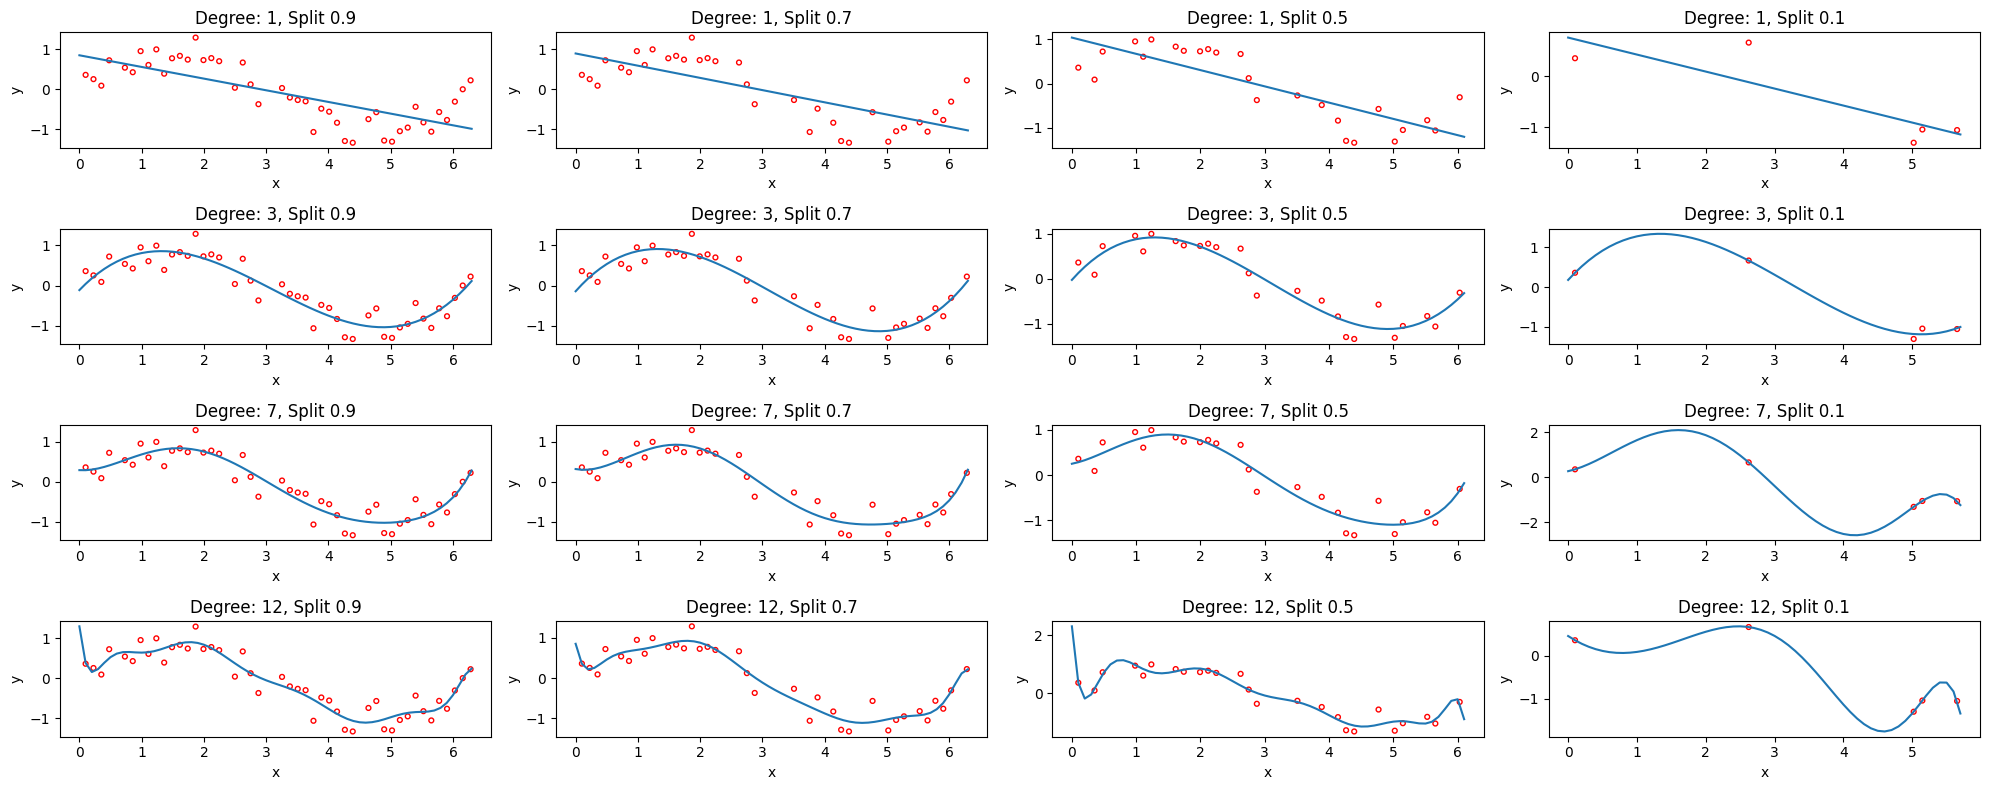

In [16]:
seed = 6
degrees = [1, 3, 7, 12]
split_ratios = [0.9, 0.7, 0.5, 0.1]

# define the structure of the figure
num_row = 4
num_col = 4
axs = plt.subplots(num_row, num_col, figsize=(20, 8))[1]

for ind, split_ratio in enumerate(split_ratios):
    for ind_d, degree in enumerate(degrees):
        x_tr, x_te, y_tr, y_te, w = train_test_split_demo(
            x, y, degree, split_ratio, seed
        )
        plot_fitted_curve(y_tr, x_tr, w, degree, axs[ind_d][ind % num_col])
        axs[ind_d][ind].set_title(f"Degree: {degree}, Split {split_ratio}")
plt.tight_layout()

Your graph should look like this:

![alt text](split_demo.png)

# Ridge Regression
Please fill in the function below.

In [17]:
def ridge_regression(y, tx, lambda_):
    """implement ridge regression.

    Args:
        y: numpy array of shape (N,), N is the number of samples.
        tx: numpy array of shape (N,D), D is the number of features.
        lambda_: scalar.

    Returns:
        w: optimal weights, numpy array of shape(D,), D is the number of features.

    >>> ridge_regression(np.array([0.1,0.2]), np.array([[2.3, 3.2], [1., 0.1]]), 0)
    array([ 0.21212121, -0.12121212])
    >>> ridge_regression(np.array([0.1,0.2]), np.array([[2.3, 3.2], [1., 0.1]]), 1)
    array([0.03947092, 0.00319628])
    """ 
    A = tx.T.dot(tx) + 2 * tx.shape[0] * lambda_ * np.eye(tx.shape[1])
    b = tx.T.dot(y)
    w = np.linalg.solve(A, b)
    return w

In [18]:
test(ridge_regression)

✅ Your `ridge_regression` passed 2 tests.


In [19]:
def ridge_regression_demo(x, y, degree, ratio, seed):
    """ridge regression demo."""
    # define parameter
    lambdas = np.logspace(-5, 0, 15)

    # split data into train and test sets
    x_tr, x_te, y_tr, y_te = split_data(x, y, ratio, seed)

    # form train and test data with polynomial basis function
    x_tr_poly = build_poly(x_tr, degree)
    x_te_poly = build_poly(x_te, degree)

    rmse_tr = []
    rmse_te = []
    for ind, lambda_ in enumerate(lambdas):
        w = ridge_regression(y_tr, x_tr_poly, lambda_)
        rmse_tr.append(np.sqrt(compute_loss(y_tr, x_tr_poly, w, loss_type="mse")))
        rmse_te.append(np.sqrt(compute_loss(y_te, x_te_poly, w, loss_type="mse")))
        print(
            "proportion={p}, degree={d}, lambda={l:.3f}, Training RMSE={tr:.3f}, Testing RMSE={te:.3f}".format(
                p=ratio, d=degree, l=lambda_, tr=rmse_tr[ind], te=rmse_te[ind]
            )
        )
    plot_train_test(rmse_tr, rmse_te, lambdas, degree)

Demo time

proportion=0.5, degree=7, lambda=0.000, Training RMSE=0.161, Testing RMSE=0.239
proportion=0.5, degree=7, lambda=0.000, Training RMSE=0.161, Testing RMSE=0.238
proportion=0.5, degree=7, lambda=0.000, Training RMSE=0.161, Testing RMSE=0.238
proportion=0.5, degree=7, lambda=0.000, Training RMSE=0.161, Testing RMSE=0.237
proportion=0.5, degree=7, lambda=0.000, Training RMSE=0.161, Testing RMSE=0.236
proportion=0.5, degree=7, lambda=0.001, Training RMSE=0.162, Testing RMSE=0.236
proportion=0.5, degree=7, lambda=0.001, Training RMSE=0.162, Testing RMSE=0.233
proportion=0.5, degree=7, lambda=0.003, Training RMSE=0.163, Testing RMSE=0.226
proportion=0.5, degree=7, lambda=0.007, Training RMSE=0.164, Testing RMSE=0.214
proportion=0.5, degree=7, lambda=0.016, Training RMSE=0.167, Testing RMSE=0.200
proportion=0.5, degree=7, lambda=0.037, Training RMSE=0.174, Testing RMSE=0.195
proportion=0.5, degree=7, lambda=0.085, Training RMSE=0.187, Testing RMSE=0.211
proportion=0.5, degree=7, lambda=0.193, 

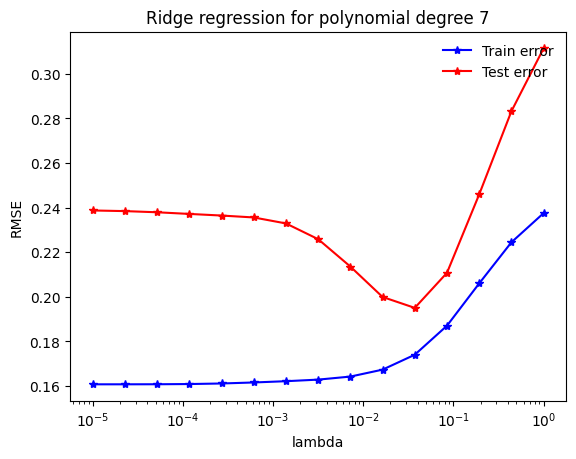

In [20]:
seed = 56
degree = 7
split_ratio = 0.5
ridge_regression_demo(x, y, degree, split_ratio, seed)

Your plot should look like:

![alt text](ridge_regression.png)